## 01. Importar Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("models", exist_ok=True)  # crea carpeta en models
from pickle import dump
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



### Descripción de las columnas
Cada fila representa un vino. Las columnas describen su composición química:

fixed acidity, volatile acidity, citric acid

residual sugar, chlorides

free sulfur dioxide, total sulfur dioxide

density, pH, sulphates, alcohol



### Cargar datos

In [ ]:
data_url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
wine_df = pd.read_csv(data_url, sep=";")  #sep es el separador de columnas en el dataset

wine_raw = wine_df.copy()

print(wine_df.shape)
wine_df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 02. Dimensiones

In [55]:
print(f"Dimensiones del dataset: {wine_df.shape[0]} filas y {wine_df.shape[1]} columnas\n")
df.shape

Dimensiones del dataset: 1599 filas y 12 columnas



(1599, 1)

In [56]:
print("Primeras 5 filas del dataset:")
print(wine_df.head())

Primeras 5 filas del dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8  

## 03. Exploracion de datos

In [62]:
# Información general del dataset
print("Información del dataset:")
print(wine_df.info())



# Distribución de la variable objetivo
#print("\n🎯 Distribución de calidad del vino:")
#print(wine_df['label'].value_counts().sort_index())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


### 3.1 La columna objetivo es label:

0 = Baja calidad

1 = Calidad media

2 = Alta calidad

creamos la columna label y clasificamos los valores de la columna quality

In [63]:
def clasificar_calidad(quality_valores):
    if quality_valores <= 5:
        return 0  # Baja calidad
    elif quality_valores == 6:
        return 1  # Media calidad
    else:
        return 2  # Alta calidad

wine_df['label'] = wine_df['quality'].apply(clasificar_calidad)

# Verificamos que se creó correctamente
print("✅ Columna 'label' creada correctamente!\n")
print("Distribución original de 'quality':")
print(wine_df['quality'].value_counts().sort_index())
print("\n🎯 Distribución de calidad del vino (label):")
print(wine_df['label'].value_counts().sort_index())

✅ Columna 'label' creada correctamente!

Distribución original de 'quality':
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

🎯 Distribución de calidad del vino (label):
label
0    744
1    638
2    217
Name: count, dtype: int64


## separacion de variables

In [43]:
features = wine_df.drop(columns=["quality", "label"])
target = wine_df["label"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=17, stratify=target)

In [45]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

## 04. Entrena el modelo KNN:

Separa las variables independientes (X) del objetivo (y).



Divide en conjunto de entrenamiento y prueba (80/20).



Escala los datos si es necesario (¡muy recomendable con KNN!).



Entrena el modelo con un valor de k inicial.

In [46]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_std, y_train)

base_predictions = knn_base.predict(X_test_std)

In [47]:
acc = accuracy_score(y_test, base_predictions)
conf_mat = confusion_matrix(y_test, base_predictions)
report = classification_report(y_test, base_predictions)

print("Accuracy:", acc)
print("\nMatriz de confusión:\n", conf_mat)
print("\nReporte de clasificación:\n", report)

Accuracy: 0.6125

Matriz de confusión:
 [[106  38   5]
 [ 41  78   9]
 [  9  22  12]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.68      0.71      0.70       149
           1       0.57      0.61      0.59       128
           2       0.46      0.28      0.35        43

    accuracy                           0.61       320
   macro avg       0.57      0.53      0.54       320
weighted avg       0.60      0.61      0.60       320



In [48]:
k_range = list(range(1, 21))
accuracy_results = []

for neighbors in k_range:
    knn_tmp = KNeighborsClassifier(n_neighbors=neighbors)
    knn_tmp.fit(X_train_std, y_train)
    preds = knn_tmp.predict(X_test_std)
    accuracy_results.append(accuracy_score(y_test, preds))

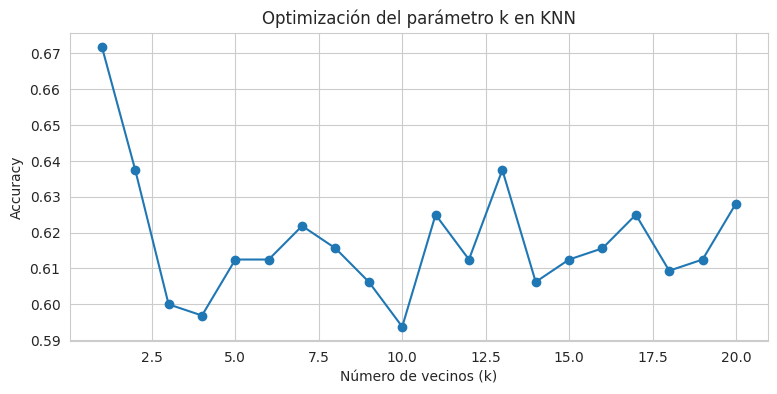

In [49]:
plt.figure(figsize=(9, 4))
plt.plot(k_range, accuracy_results, marker="o")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.title("Optimización del parámetro k en KNN")
plt.grid(True)
plt.show()

In [50]:
best_k = k_range[np.argmax(accuracy_results)]
print(f"Mejor k encontrado: {best_k}")

Mejor k encontrado: 1


In [51]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_std, y_train)

dump(knn_final, open("models/knn_wine_model.sav", "wb"))

In [52]:
def predict_wine(notes):
    notes_scaled = scaler.transform([notes])
    prediction = knn_final.predict(notes_scaled)[0]

    messages = {
        0: "El vino es de baja calidad 🍷",
        1: "El vino es de calidad media 🍷",
        2: "El vino es de alta calidad 🍷"
    }

    return messages[prediction]

In [53]:
sample_wine = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
print(predict_wine(sample_wine))

El vino es de baja calidad 🍷


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
